In [69]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shree1992/housedata/output.csv
/kaggle/input/datasets/shree1992/housedata/data.csv
/kaggle/input/datasets/shree1992/housedata/data.dat


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression



sns.set_theme(style='whitegrid', palette='muted')
print('All packages loaded successfully')

All packages loaded successfully


In [71]:
df = pd.read_csv('/kaggle/input/datasets/shree1992/housedata/data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [72]:
df.value_counts('statezip')

statezip
WA 98103    148
WA 98052    135
WA 98117    132
WA 98115    130
WA 98006    110
           ... 
WA 98047      6
WA 98288      3
WA 98050      2
WA 98354      2
WA 98068      1
Name: count, Length: 77, dtype: int64

In [73]:
# Parse date
df['date'] = pd.to_datetime(df['date'])
df['year']           = df['date'].dt.year
df['month']          = df['date'].dt.month
df['day_of_week']    = df['date'].dt.dayofweek
df['days_since_start'] = (df['date'] - df['date'].min()).dt.days
df.drop(columns=['date'], inplace=True)

# Drop low-signal columns
df.drop(columns=['country', 'street', 'sqft_above', 'yr_renovated'], inplace=True)

# Extract numeric zip code
df['zipcode'] = df['statezip'].str.extract(r'(\d+)').astype(int)
df.drop(columns=['statezip'], inplace=True)

print('Columns after feature engineering:', df.columns.tolist())

Columns after feature engineering: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_basement', 'yr_built', 'city', 'year', 'month', 'day_of_week', 'days_since_start', 'zipcode']


In [74]:
# Log-transform price for outlier detection (NOT used as a feature)
df['price_log'] = np.log1p(df['price'])

# Convert yr_built → house_age
df['house_age'] = 2024 - df['yr_built']
df.drop(columns=['yr_built'], inplace=True)

# Remove outliers via IQR on key columns
for col in ['sqft_living', 'sqft_lot', 'sqft_basement', 'price_log']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

# Remove zero-price rows, fix zero bed/bath with median
df = df[df['price'] > 0]
df['bedrooms']  = df['bedrooms'].replace(0, df['bedrooms'].median())
df['bathrooms'] = df['bathrooms'].replace(0, df['bathrooms'].median())

print(f'Final shape: {df.shape}')

Final shape: (3854, 18)


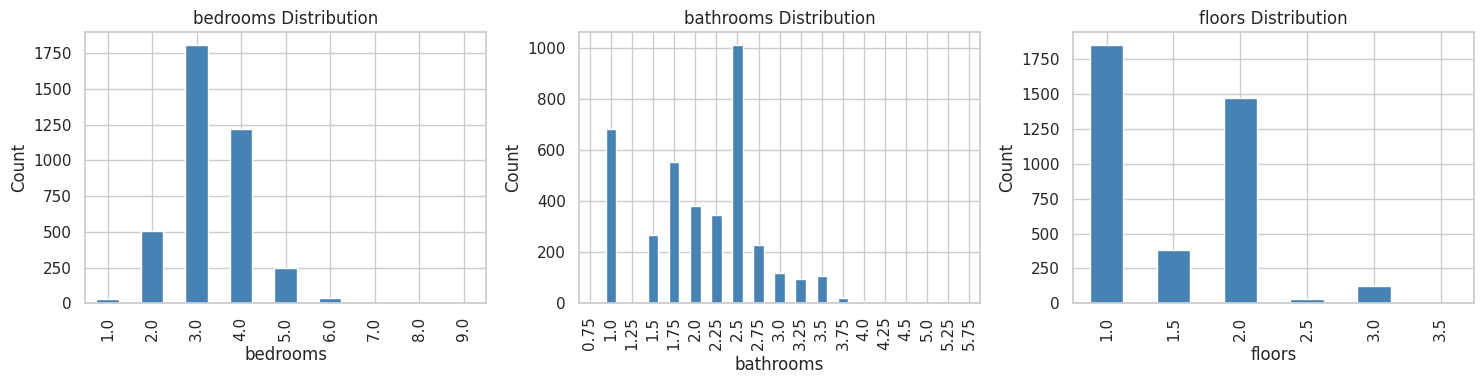

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['bedrooms', 'bathrooms', 'floors']):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col); ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

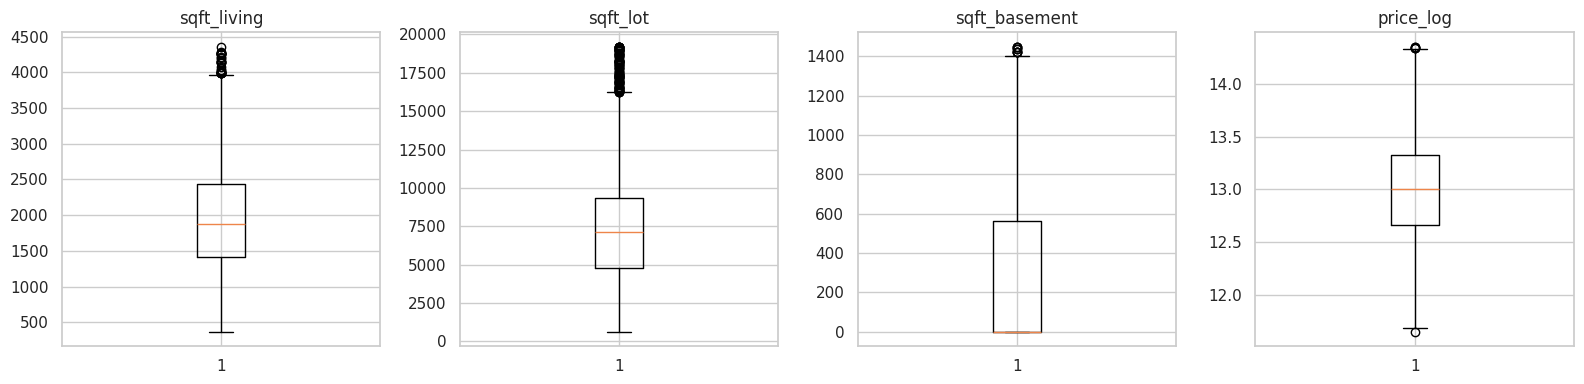

In [76]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['sqft_living', 'sqft_lot', 'sqft_basement', 'price_log']):
    axes[list(axes).index(ax)].boxplot(df[col])
    axes[list(axes).index(ax)].set_title(col)
plt.tight_layout()
plt.show()

In [77]:
y = df['price_log'].copy()
X = df.drop(columns=['price', 'price_log'])   # <-- critical fix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Target encoding for city (leak-free: computed on train only)
train_temp = X_train.copy()
train_temp['target'] = y_train
city_means = train_temp.groupby('city')['target'].mean()

X_train['city_encoded'] = X_train['city'].map(city_means)
X_test['city_encoded']  = X_test['city'].map(city_means).fillna(y_train.mean())
X_train.drop(columns=['city'], inplace=True)
X_test.drop(columns=['city'], inplace=True)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'X_train: {X_train_scaled.shape}  |  X_test: {X_test_scaled.shape}')
print('Features:', X_train.columns.tolist())

X_train: (3083, 16)  |  X_test: (771, 16)
Features: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_basement', 'year', 'month', 'day_of_week', 'days_since_start', 'zipcode', 'house_age', 'city_encoded']


In [78]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
lr_r2  = r2_score(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_lr))

# 5. Print
print('Linear Regression (Corrected)')
print(f'R² Score : {lr_r2:.4f}')
print(f'MSE      : {lr_mse:.4f}')
print(f'MAE ($$) : ${lr_mae:,.2f}')

Linear Regression (Corrected)
R² Score : 0.7320
MSE      : 0.0628
MAE ($$) : $95,591.34


In [79]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.01)  
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge R²:", r2_score(y_test, y_pred_ridge))

Ridge R²: 0.7320017068880867


In [80]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso R²:", r2_score(y_test, y_pred_lasso))

Lasso R²: 0.7254873446571635


In [81]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

rf_r2  = r2_score(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_rf))

print('Random Forest (Corrected)')
print(f'R² Score : {rf_r2:.4f}')
print(f'MSE      : {rf_mse:.4f}')
print(f'MAE ($$) : ${rf_mae:,.2f}')

Random Forest (Corrected)
R² Score : 0.8025
MSE      : 0.0463
MAE ($$) : $80,215.29


In [82]:
gbr_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
gbr_model.fit(X_train_scaled, y_train)

y_pred_gbr = gbr_model.predict(X_test_scaled)

gbr_r2  = r2_score(y_test, y_pred_gbr)
gbr_mse = mean_squared_error(y_test, y_pred_gbr)
gbr_mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_gbr))

print('Gradient Boosting Regressor')
print(f'R² Score : {gbr_r2:.4f}')
print(f'MSE      : {gbr_mse:.4f}')
print(f'MAE ($$) : ${gbr_mae:,.2f}')

Gradient Boosting Regressor
R² Score : 0.8495
MSE      : 0.0353
MAE ($$) : $69,964.43


In [83]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Example dataset 
from sklearn.datasets import fetch_california_housing

# Create model
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.1954404784224171
R2 Score: 0.8369391500240158


In [84]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_basement', 'city', 'year',
       'month', 'day_of_week', 'days_since_start', 'zipcode', 'price_log',
       'house_age'],
      dtype='object')